# Лабораторная работа: Сравнение линейных и нелинейных моделей классификации
## (на примере диагностики рака молочной железы)

### Цель работы
Цель данной лабораторной работы — практически изучить и сравнить три подхода к решению задачи бинарной классификации:
1.  **Линейная модель** (логистическая регрессия).
2.  **Метод опорных векторов (SVM)**.
3.  **Нелинейная модель** (дерево решений).

В качестве предметной области выбран реальный медицинский датасет **Breast Cancer Wisconsin**, позволяющий решать задачу диагностики опухолей.

### Описание датасета
- **Источник:** Университет Висконсина, данные получены в результате тонкоигольной аспирационной биопсии.
- **Задача:** По морфологическим характеристикам ядер клеток определить, является ли опухоль **доброкачественной (Benign, 0)** или **злокачественной (Malignant, 1)**.
- **Размер выборки:** 569 наблюдений.
- **Признаки:** 30 числовых признаков (радиус, текстура, периметр, площадь, гладкость, компактность, вогнутость и др.). Каждый представлен в трех вариантах: среднее значение (`_mean`), стандартная ошибка (`_se`) и наихудшее значение (`_worst`).
- **Целевая переменная:** `diagnosis` (M/B).

### Этапы работы
В работе последовательно выполняются следующие шаги:
1. Загрузка и первичный анализ данных.
2. Предобработка (удаление служебных столбцов, кодирование меток, проверка пропусков и дубликатов).
3. Разведочный анализ данных (EDA) с построением визуализаций.
4. Стандартизация признаков и разделение выборки.
5. Обучение моделей и оценка их качества.
6. Сравнение моделей (метрики, ROC-кривые, матрицы ошибок).
7. Анализ важности признаков и извлечение правил дерева решений.

## Описание используемого датасета

**Источник данных:** University of Wisconsin Hospitals, клиническое исследование, проведённое в 1990-х годах.

**Структура данных:**
- **Количество наблюдений:** 569
- **Количество признаков:** 30 числовых
- **Целевая переменная:** `diagnosis` — имеет два значения: `M` (malignant, злокачественная) и `B` (benign, доброкачественная)

**Признаки сгруппированы по трём категориям для каждого из 10 параметров:**
- `_mean` — среднее значение параметра по всем клеткам образца
- `_se` — стандартная ошибка измерения
- `_worst` — среднее значение трёх худших (наиболее патологических) клеток

**Что означают ключевые параметры:**
- `radius` — среднее расстояние от центра ядра до точек на его периметре
- `texture` — стандартное отклонение значений оттенков серого на изображении
- `perimeter` — периметр ядра
- `area` — площадь ядра
- `smoothness` — локальная вариация длин радиусов
- `compactness` — (периметр² / площадь) — 1.0
- `concavity` — степень вогнутости контура ядра
- `concave points` — количество вогнутых участков контура
- `symmetry` — симметричность ядра
- `fractal_dimension` — фрактальная размерность контура

**Целевая переменная после кодирования:**
- `0` (Benign) — доброкачественная опухоль (357 образцов, 62.7%)
- `1` (Malignant) — злокачественная опухоль (212 образцов, 37.3%)

Наблюдается небольшой дисбаланс классов: доброкачественных случаев примерно в 1.7 раза больше. Это важно учитывать при выборе метрик качества — accuracy может быть обманчиво высокой, если модель будет просто всегда предсказывать «доброкачественную».

In [36]:
# 1. Установка и импорт
!pip install -q kagglehub scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# Настройка красивых графиков
sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Все библиотеки загружены")

Все библиотеки загружены



### Машинное обучение (sklearn):
- `train_test_split` — разбиение данных на обучающую и тестовую выборки
- `StandardScaler` — стандартизация признаков (приведение к нулевому среднему и единичной дисперсии)
- `LabelEncoder` — преобразование текстовых меток классов в числа
- `LogisticRegression`, `SVC`, `DecisionTreeClassifier` — три модели, которые мы будем сравнивать
- `plot_tree` — визуализация структуры дерева решений
- `metrics` — набор метрик для оценки качества (accuracy, precision, recall, f1, roc_auc, confusion_matrix)

**Почему мы настраиваем размеры графиков глобально:** через `plt.rcParams` мы задаём единый стиль для всех визуализаций, чтобы ноутбук выглядел профессионально и все графики были читаемы при любом масштабе.

In [37]:
# 2. Загрузка и первичный просмотр
import kagglehub

path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
df = pd.read_csv(f"{path}/data.csv")

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Размер данных: (569, 33)

Первые 5 строк:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 2. Загрузка и первичный анализ данных

**Загрузка:**
Данные загружаются через `kagglehub.dataset_download`.

**Первичный осмотр:**
- `df.shape` показывает размерность: 569 строк × 33 столбца.
- `df.head()` выводит первые 5 строк. Видно, что:
  - Есть столбцы `id` (уникальный идентификатор) и `Unnamed: 32` (пустой).
  - Целевая переменная `diagnosis` представлена строками `M` (Malignant) и `B` (Benign).
  - Остальные признаки — числовые.

**Зачем это нужно?** Чтобы понять структуру данных, выявить служебные столбцы и определить, какие преобразования потребуются.

### 3. Предобработка данных

**Шаг 1. Удаление служебных столбцов**
Удаляем столбцы `id` (не влияет на диагноз) и `Unnamed: 32` (полностью состоит из пропусков). После удаления остается 31 столбец.

**Шаг 2. Кодирование целевой переменной**
Модели `sklearn` работают только с числами. Преобразуем `M` → `1`, `B` → `0` с помощью `LabelEncoder`.

**Шаг 3. Проверка пропусков**
`df.isnull().sum()` показывает, что пропусков нет. Это избавляет нас от необходимости их заполнения.

**Шаг 4. Статистическая сводка**
`df.describe().T` выводит основные статистики (среднее, стандартное отклонение, минимум, квартили, максимум) для каждого признака.

**Шаг 5. Проверка дубликатов**
`df.duplicated().sum()` показывает, что дублирующихся строк нет.

**Шаг 6. Информация о типах данных**
`df.dtypes.value_counts()` показывает, что данные в основном представлены типами `float64` и `int64`.

In [38]:
# 3. ПЕРВИЧНЫЙ АНАЛИЗ И ПРЕДОБРАБОТКА ДАННЫХ

print("="*80)
print("ШАГ 1: УДАЛЕНИЕ СЛУЖЕБНЫХ СТОЛБЦОВ")
print("="*80)

# Удаляем бесполезные столбцы
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')
print("Удалены столбцы: 'id', 'Unnamed: 32'")
print(f" Новый размер данных: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"Оставшиеся столбцы: {list(df.columns[:5])} ... и ещё {len(df.columns)-5} признаков")

print("\n" + "="*80)
print("ШАГ 2: КОДИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*80)

# Кодируем диагноз
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1 (malignant), B=0 (benign)

print("Результат кодирования:")
print(f"   'M' (Malignant)  → 1")
print(f"   'B' (Benign)     → 0")
print(f"\nРаспределение после кодирования:")
print(df['diagnosis'].value_counts().rename(index={0: 'Benign (0)', 1: 'Malignant (1)'}))

print("\n" + "="*80)
print("ШАГ 3: ПРОВЕРКА НАЛИЧИЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("="*80)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_table = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент (%)': missing_percent
})
missing_table = missing_table[missing_table['Пропусков'] > 0]

if missing_table.empty:
    print("Отлично! Пропущенных значений нет (0 NaN).")
else:
    print("Обнаружены пропуски в следующих столбцах:")
    print(missing_table)

print("\n" + "="*80)
print("ШАГ 4: СТАТИСТИЧЕСКАЯ СВОДКА ПО ПРИЗНАКАМ")
print("="*80)

# Статистическая сводка для первых 10 признаков
stat_summary = df.describe().T
stat_summary = stat_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stat_summary.columns = ['Среднее', 'Стд. откл.', 'Min', '25%', 'Медиана', '75%', 'Max']

print("Статистика по первым 10 признакам (случайная выборка):")
print(stat_summary.head(10).round(2))

print("\n" + "="*80)
print("ШАГ 5: ПРОВЕРКА НА ДУБЛИКАТЫ")
print("="*80)

duplicates = df.duplicated().sum()
if duplicates == 0:
    print(" Дублирующихся строк не обнаружено.")
else:
    print(f" Найдено {duplicates} дублирующихся строк. Удаляем...")
    df = df.drop_duplicates()
    print(f"   Новый размер: {df.shape}")

print("\n" + "="*80)
print("ШАГ 6: ИНФОРМАЦИЯ О ТИПАХ ДАННЫХ")
print("="*80)

print(df.dtypes.value_counts())
print("\n Первые 5 строк после предобработки:")
df.head()

ШАГ 1: УДАЛЕНИЕ СЛУЖЕБНЫХ СТОЛБЦОВ
Удалены столбцы: 'id', 'Unnamed: 32'
 Новый размер данных: 569 строк × 31 столбцов
Оставшиеся столбцы: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean'] ... и ещё 26 признаков

ШАГ 2: КОДИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
Результат кодирования:
   'M' (Malignant)  → 1
   'B' (Benign)     → 0

Распределение после кодирования:
diagnosis
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64

ШАГ 3: ПРОВЕРКА НАЛИЧИЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
Отлично! Пропущенных значений нет (0 NaN).

ШАГ 4: СТАТИСТИЧЕСКАЯ СВОДКА ПО ПРИЗНАКАМ
Статистика по первым 10 признакам (случайная выборка):
                     Среднее  Стд. откл.     Min     25%  Медиана     75%  \
diagnosis               0.37        0.48    0.00    0.00     0.00    1.00   
radius_mean            14.13        3.52    6.98   11.70    13.37   15.78   
texture_mean           19.29        4.30    9.71   16.17    18.84   21.80   
perimeter_mean         91.97       24.30   43.

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 4. Разведочный анализ данных (EDA)

**График 1. Распределение классов**
Столбчатая диаграмма и круговая диаграмма показывают дисбаланс классов:
- 357 доброкачественных (62.7%)
- 212 злокачественных (37.3%)
Это важно для выбора метрик: accuracy может быть высокой, даже если модель всегда предсказывает "Benign".

**График 2. Корреляционная матрица**
Тепловая карта показывает корреляцию между признаками и диагнозом.
- Наиболее сильно коррелируют с диагнозом: `concave points_mean` (0.78), `perimeter_mean` (0.74), `radius_mean` (0.73).
- Это означает, что большие размеры и неправильная форма ядра чаще связаны со злокачественностью.

**График 3. Распределение ключевых признаков по классам**
Гистограммы для `area_mean`, `perimeter_mean`, `radius_mean`, `concavity_mean`. Наглядно видно, что распределения для Benign и Malignant сильно различаются — хорошая основа для классификации.

**График 4. PCA-визуализация**
Снижаем размерность с 30 до 2 главных компонент.
- Первая компонента объясняет ~44% дисперсии, вторая — ~19%.
- На графике видно, что классы хорошо разделяются даже в 2D-пространстве.

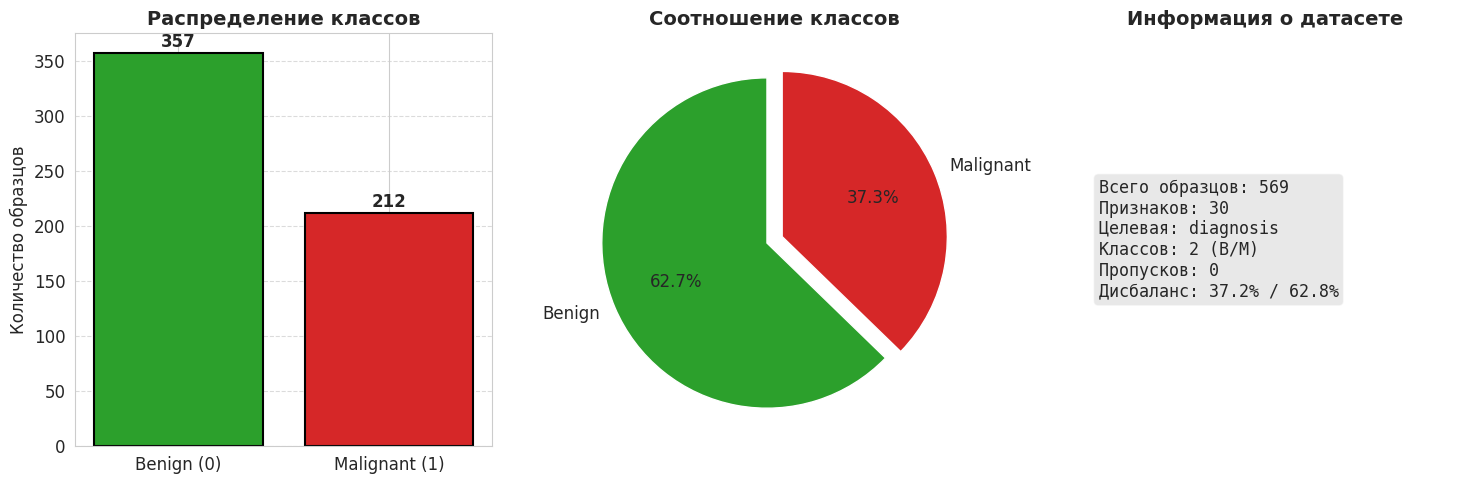

In [39]:
# 4. РАСШИРЕННАЯ ВИЗУАЛИЗАЦИЯ: распределение классов и базовый анализ
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Количество образцов по классам
class_counts = df['diagnosis'].value_counts()
colors = ['#2ca02c', '#d62728']
axes[0].bar(['Benign (0)', 'Malignant (1)'], class_counts, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество образцов', fontsize=12)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# График 2: Pie chart
axes[1].pie(class_counts, labels=['Benign', 'Malignant'], autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05), textprops={'fontsize': 12})
axes[1].set_title('Соотношение классов', fontsize=14, fontweight='bold')

# График 3: Информация о датасете
axes[2].axis('off')
info_text = f"Всего образцов: 569\nПризнаков: 30\nЦелевая: diagnosis\nКлассов: 2 (B/M)\nПропусков: 0\nДисбаланс: 37.2% / 62.8%"
axes[2].text(0.1, 0.5, info_text, fontsize=12, verticalalignment='center', fontfamily='monospace', bbox=dict(boxstyle="round", facecolor='lightgray', alpha=0.5))
axes[2].set_title('Информация о датасете', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_info.png', dpi=150, bbox_inches='tight')
plt.show()

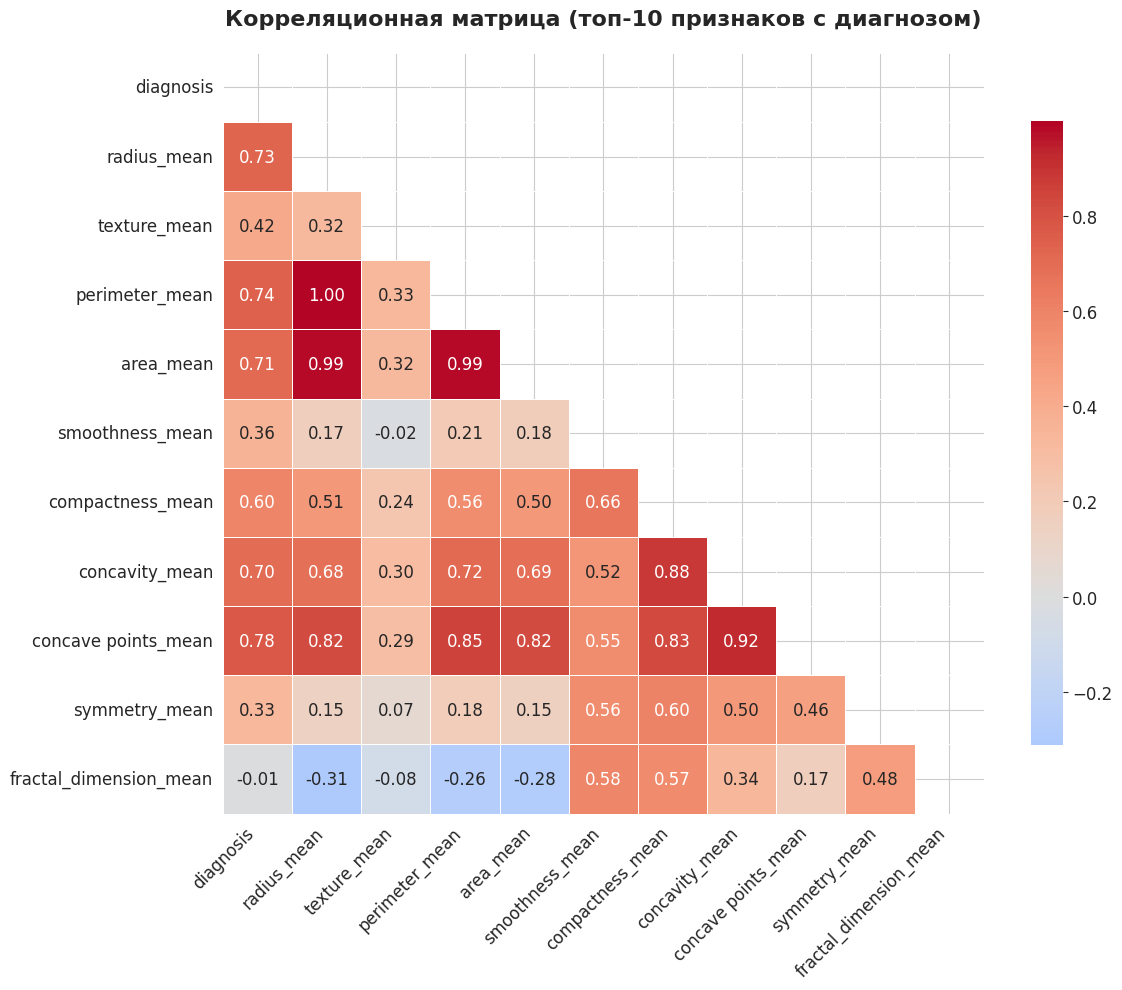


Признаки, наиболее коррелированные с диагнозом:
diagnosis                 1.000000
concave points_mean       0.776614
perimeter_mean            0.742636
radius_mean               0.730029
area_mean                 0.708984
concavity_mean            0.696360
compactness_mean          0.596534
texture_mean              0.415185
smoothness_mean           0.358560
symmetry_mean             0.330499
fractal_dimension_mean   -0.012838
Name: diagnosis, dtype: float64


In [40]:
# 5. ВИЗУАЛИЗАЦИЯ: Корреляционная матрица (топ-10 признаков с diagnosis)
# Берём первые 10 признаков + диагноз для наглядности
top_features = ['diagnosis'] + list(df.columns[1:11])  # включаем diagnosis + 10 признаков
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
heatmap = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                      center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица (топ-10 признаков с диагнозом)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nПризнаки, наиболее коррелированные с диагнозом:")
corr_with_diagnosis = corr_matrix['diagnosis'].sort_values(ascending=False)
print(corr_with_diagnosis)

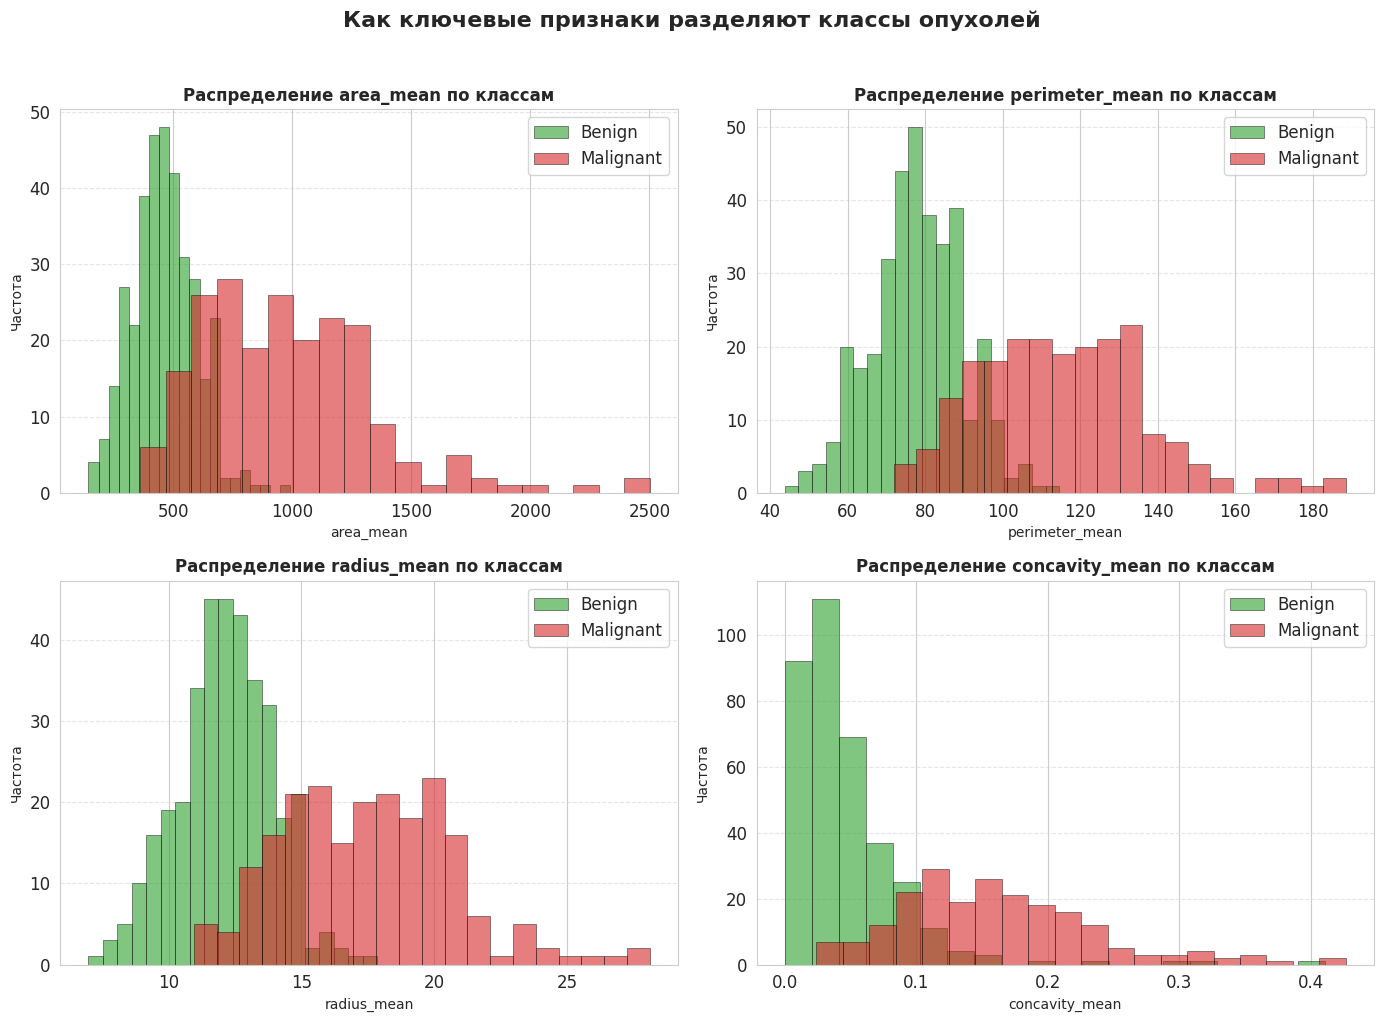

In [41]:
# 6. ВИЗУАЛИЗАЦИЯ: Распределение двух самых важных признаков по классам
important_features = ['area_mean', 'perimeter_mean', 'radius_mean', 'concavity_mean']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(important_features):
    for class_val, color, label in zip([0, 1], ['#2ca02c', '#d62728'], ['Benign', 'Malignant']):
        subset = df[df['diagnosis'] == class_val][feature]
        axes[idx].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'Распределение {feature} по классам', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Как ключевые признаки разделяют классы опухолей', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Подготовка данных к обучению

**1. Выделение признаков и целевой переменной**
- `X` — все столбцы, кроме `diagnosis`.
- `y` — столбец `diagnosis`.

**2. Стандартизация**
Применяем `StandardScaler`: `(X - mean) / std`. Это необходимо для корректной работы логистической регрессии и SVM.

**3. Разделение выборки**
`train_test_split` с параметрами:
- `test_size=0.2` (20% — тестовая выборка).
- `random_state=42` (для воспроизводимости).
- `stratify=y` (сохраняем пропорцию классов).

Результат: 455 обучающих и 114 тестовых образцов.

In [42]:
# 7. Подготовка данных к обучению
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Стандартизация выполнена (mean≈0, std≈1)")

Обучающая выборка: 455 образцов
Тестовая выборка: 114 образцов
Стандартизация выполнена (mean≈0, std≈1)


### 6. Обучение моделей

Обучаем четыре модели:

| Модель | Ядро | Параметры | Назначение |
|--------|------|-----------|-------------|
| Logistic Regression | — | `max_iter=1000` | Линейная модель, стандартный baseline |
| SVM (RBF) | RBF | `probability=True` | Нелинейная модель, способная строить сложные границы |
| Decision Tree | — | `max_depth=5, min_samples_split=10` | Нелинейная модель с ограничением сложности (предотвращение переобучения) |
| SVM (Linear) | Linear | `probability=True` | Линейная версия SVM для сравнения |

Все модели обучаются на одинаковых данных, чтобы сравнение было корректным.

In [43]:
# 8. Обучение трёх моделей
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF kernel)": SVC(kernel='rbf', random_state=42, probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=10)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} обучена")

# Дополнительно обучим SVM с линейным ядром для сравнения
svm_linear = SVC(kernel='linear', random_state=42, probability=True)
svm_linear.fit(X_train, y_train)
trained_models["SVM (Linear)"] = svm_linear
print("SVM (Linear) обучена")

Logistic Regression обучена
SVM (RBF kernel) обучена
Decision Tree обучена
SVM (Linear) обучена


### 7. Оценка качества моделей

**Используемые метрики:**
1. **Accuracy** — доля правильных ответов.
2. **Precision** — точность: из предсказанных злокачественных — сколько действительно злокачественных.
3. **Recall** — полнота: из всех реальных злокачественных — сколько модель нашла.
4. **F1-score** — среднее гармоническое Precision и Recall.
5. **ROC-AUC** — интегральная метрика качества разделения.

**Для каждой модели** выводим:
- Таблицу с метриками.
- Classification Report (с разбивкой по классам).
- Сводную таблицу сравнения.

**Анализ результатов (по данным из ноутбука):**
- **SVM (RBF kernel)** показала лучший результат: Accuracy 0.974, Precision 1.000, F1 0.963.
- **Логистическая регрессия и SVM Linear** близки (Accuracy ~0.965).
- **Дерево решений** отстает (Accuracy 0.895) — это связано с ограничением глубины, но зато оно интерпретируемо.

In [44]:
# 9. ОЦЕНКА КАЧЕСТВА с расширенными метриками
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0

    results.append({
        "Модель": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

results_df = pd.DataFrame(results)
print("\nСводная таблица результатов:")
print(results_df.to_string(index=False))


 Logistic Regression
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1-score:  0.9512
ROC-AUC:   0.9960

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


 SVM (RBF kernel)
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1-score:  0.9630
ROC-AUC:   0.9954

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


 Decision Tree
Accuracy:  0.8947
Precision: 0.9167
Recall:    0.7857
F1-scor

### 8. Визуализация сравнения моделей

**График 5. Сравнение метрик (групповая гистограмма)**
- По оси X — модели.
- По оси Y — значения метрик (Accuracy, Precision, Recall, F1, ROC-AUC).
- Гистограмма позволяет наглядно сравнить все модели по всем метрикам одновременно.

**График 6. ROC-кривые**
- По оси X — False Positive Rate (1 — специфичность).
- По оси Y — True Positive Rate (чувствительность).
- Чем ближе кривая к левому верхнему углу, тем лучше модель.
- AUC (Area Under Curve) — числовая метрика качества. У SVM (RBF) AUC = 0.995, что близко к идеальному значению 1.0.

**График 7. Матрицы ошибок (Confusion Matrix)**
- Строки — истинные классы, столбцы — предсказанные.
- Диагональ — верно классифицированные объекты.
- Позволяет увидеть, какие ошибки допускает модель (ложноположительные или ложноотрицательные).
- Для медицинской диагностики ошибка **False Negative** (пропустить рак) критичнее, чем False Positive.

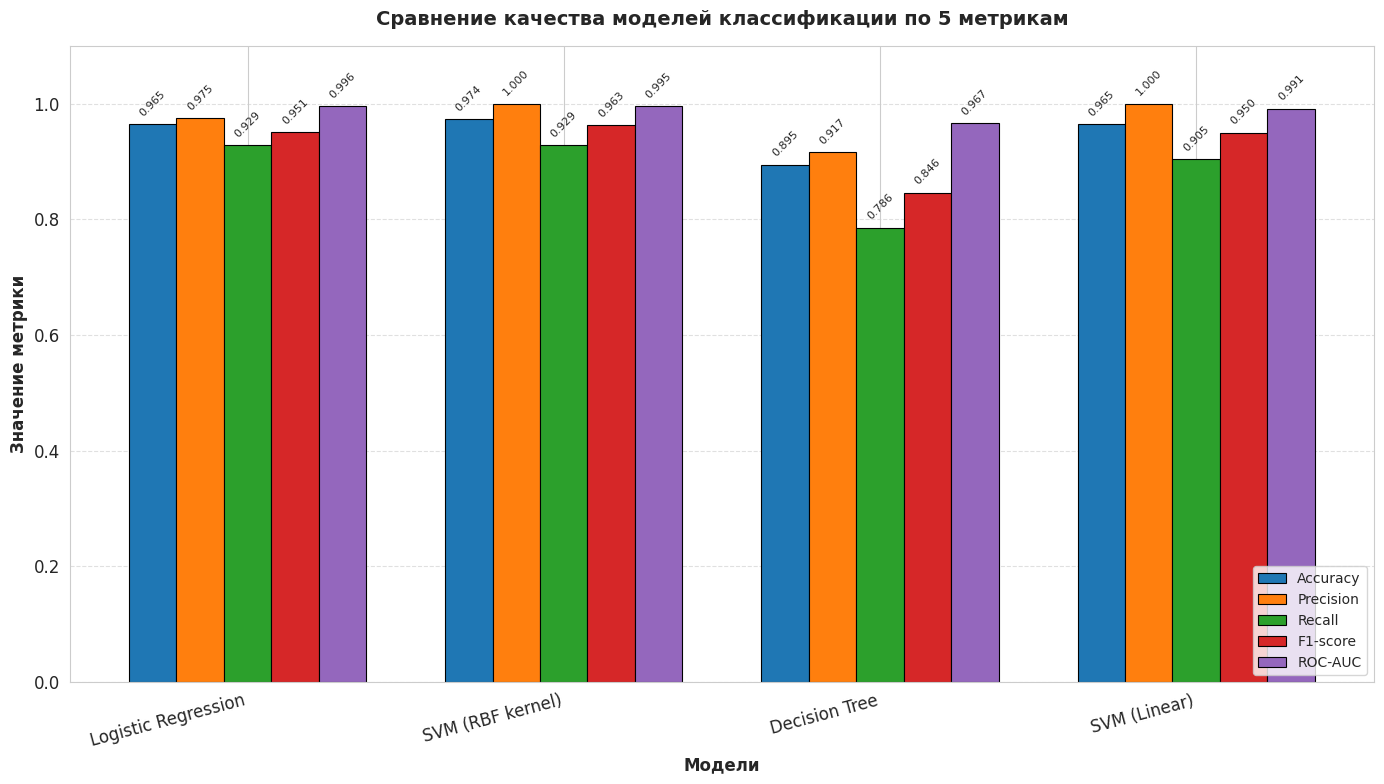

In [45]:
# 10. ВИЗУАЛИЗАЦИЯ: Сравнение всех метрик для всех моделей
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(results_df))
width = 0.15
colors_metrics = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (metric, color) in enumerate(zip(metrics, colors_metrics)):
    values = results_df[metric].values
    bars = ax.bar(x + i*width - 0.3, values, width, label=metric, color=color, edgecolor='black', linewidth=0.8)
    # Добавляем значения на столбцы
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xlabel('Модели', fontsize=12, fontweight='bold')
ax.set_ylabel('Значение метрики', fontsize=12, fontweight='bold')
ax.set_title('Сравнение качества моделей классификации по 5 метрикам', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Модель'], rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

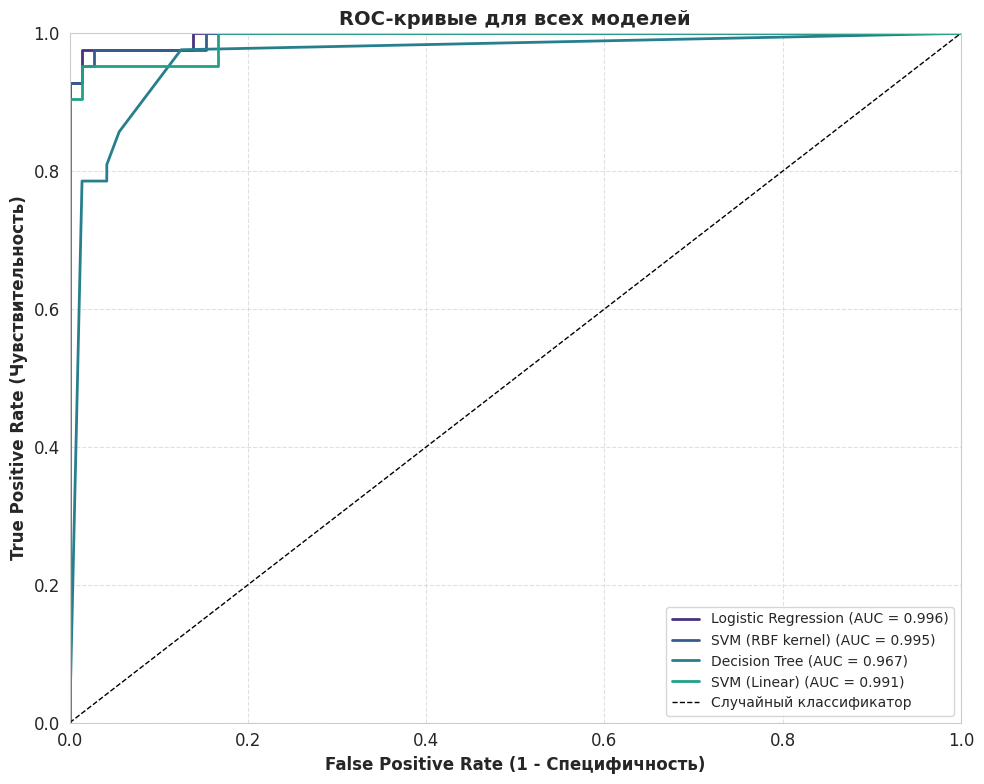

In [46]:
# 11. ВИЗУАЛИЗАЦИЯ: ROC-кривые для всех моделей
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
plt.xlabel('False Positive Rate (1 - Специфичность)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Чувствительность)', fontsize=12, fontweight='bold')
plt.title('ROC-кривые для всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(linestyle='--', alpha=0.6)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

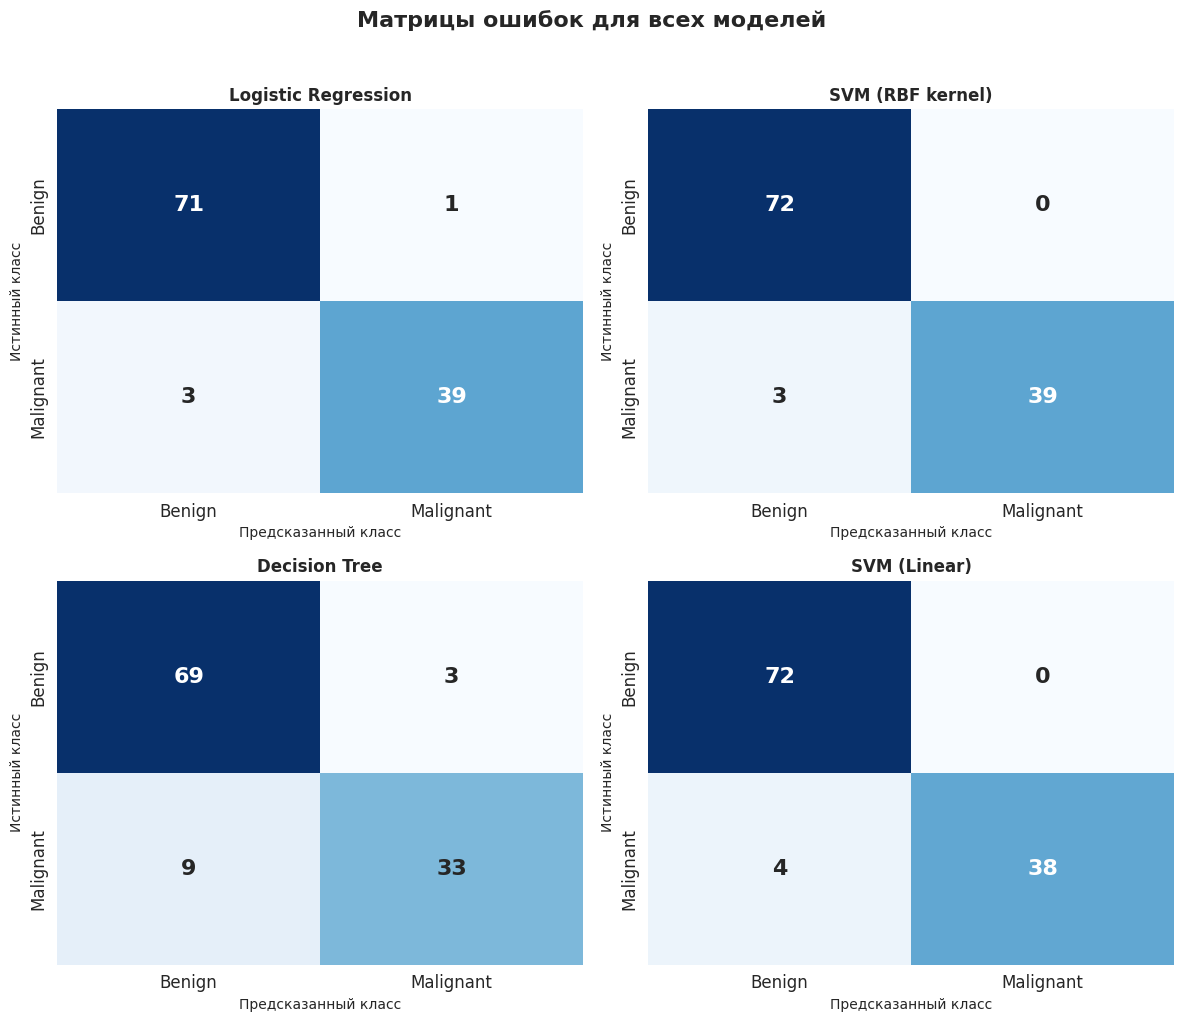

In [47]:
# 12. ВИЗУАЛИЗАЦИЯ: Матрицы ошибок (Confusion Matrices)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                cbar=False, annot_kws={'size': 16, 'weight': 'bold'})
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Предсказанный класс', fontsize=10)
    axes[idx].set_ylabel('Истинный класс', fontsize=10)

plt.suptitle('Матрицы ошибок для всех моделей', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 9. Анализ важности признаков (Feature Importance)

Дерево решений позволяет оценить, какие признаки внесли наибольший вклад в построение модели.

**Метод:** `model.feature_importances_` вычисляет важность каждого признака на основе критерия Джини (Gini impurity).

**График 8. Топ-15 признаков по важности**
- Наибольшую важность имеет **`perimeter_worst`** (0.808).
- Далее следуют **`concave points_worst`** (0.076), **`texture_mean`** (0.033), **`smoothness_worst`** (0.028), **`area_mean`** (0.025).
- Это коррелирует с корреляционной матрицей и подтверждает, что размеры и форма клеток — ключевые маркеры злокачественности.

**Зачем это нужно?**
- Во-первых, для интерпретации модели: мы понимаем, на какие признаки модель опирается.
- Во-вторых, для возможного сокращения числа признаков (feature selection).

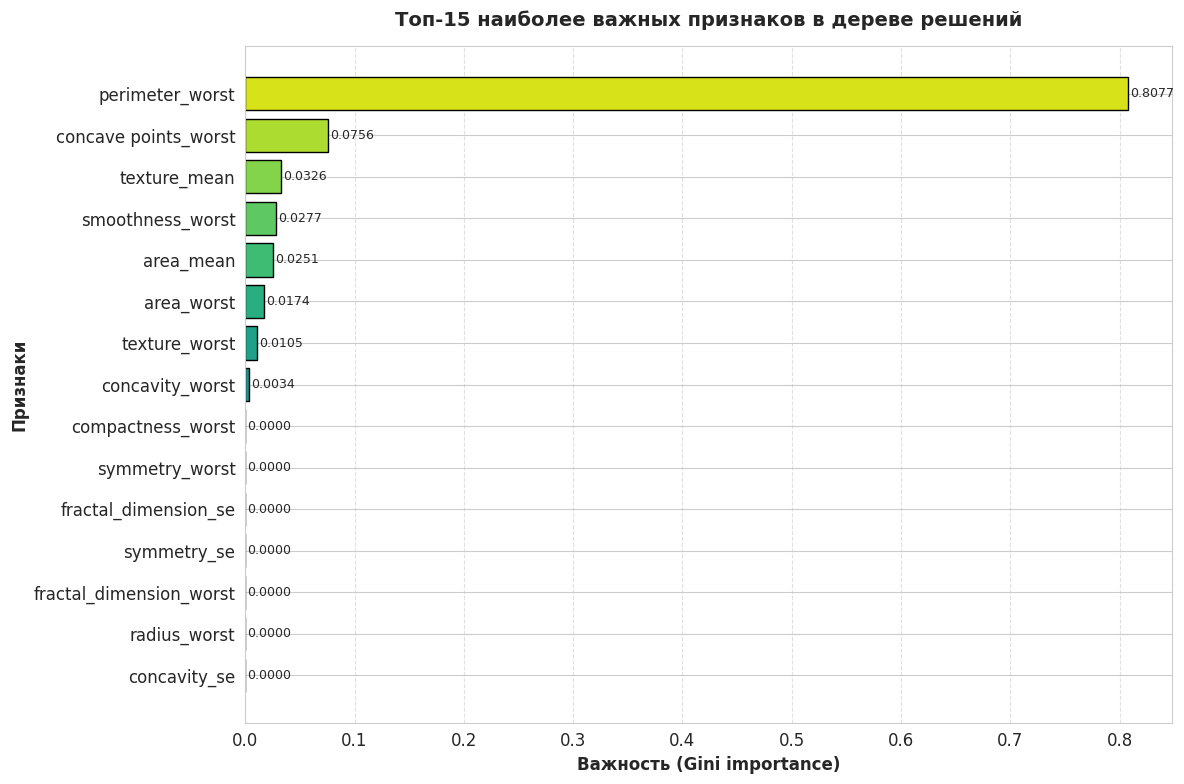


🌟 Топ-5 самых важных признаков:
1. perimeter_worst: 0.8077
2. concave points_worst: 0.0756
3. texture_mean: 0.0326
4. smoothness_worst: 0.0277
5. area_mean: 0.0251


In [48]:
# 13. ВАЖНОСТЬ ПРИЗНАКОВ в дереве решений
tree_model = trained_models["Decision Tree"]
importances = tree_model.feature_importances_
feature_names = X.columns

# Сортируем и берём топ-15
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 8))
colors = sns.color_palette("viridis", 15)[::-1]
bars = plt.barh(range(15), importances[indices], color=colors, edgecolor='black', linewidth=1)

plt.yticks(range(15), feature_names[indices])
plt.xlabel('Важность (Gini importance)', fontsize=12, fontweight='bold')
plt.ylabel('Признаки', fontsize=12, fontweight='bold')
plt.title('Топ-15 наиболее важных признаков в дереве решений', fontsize=14, fontweight='bold', pad=15)

# Добавляем значения на бары
for i, (bar, val) in enumerate(zip(bars, importances[indices])):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
             va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🌟 Топ-5 самых важных признаков:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

### 10. Визуализация дерева решений и извлечение правил

**График 9. Дерево решений (глубина = 5)**
- Каждый узел показывает:
  - Условие (например, `perimeter_worst <= 0.16`).
  - Количество объектов в узле (`samples`).
  - Распределение классов (`value = [Benign, Malignant]`).
  - Доминирующий класс (цвет узла).
- Листья (конечные узлы) содержат окончательные предсказания.

**Текстовые правила дерева (export_text)**
Дерево можно преобразовать в набор правил вида:

|--- perimeter_worst <= 0.16
| |--- concave points_worst <= 0.70
| | |--- area_mean <= 0.12 -> Benign
| | |--- area_mean > 0.12 -> Malignant

Эти правила можно использовать:
- Для интерпретации.
- Для внедрения в экспертные системы.
- Для верификации врачами.

**Вывод:** Дерево решений уступает SVM по точности, но выигрывает в прозрачности и интерпретируемости.

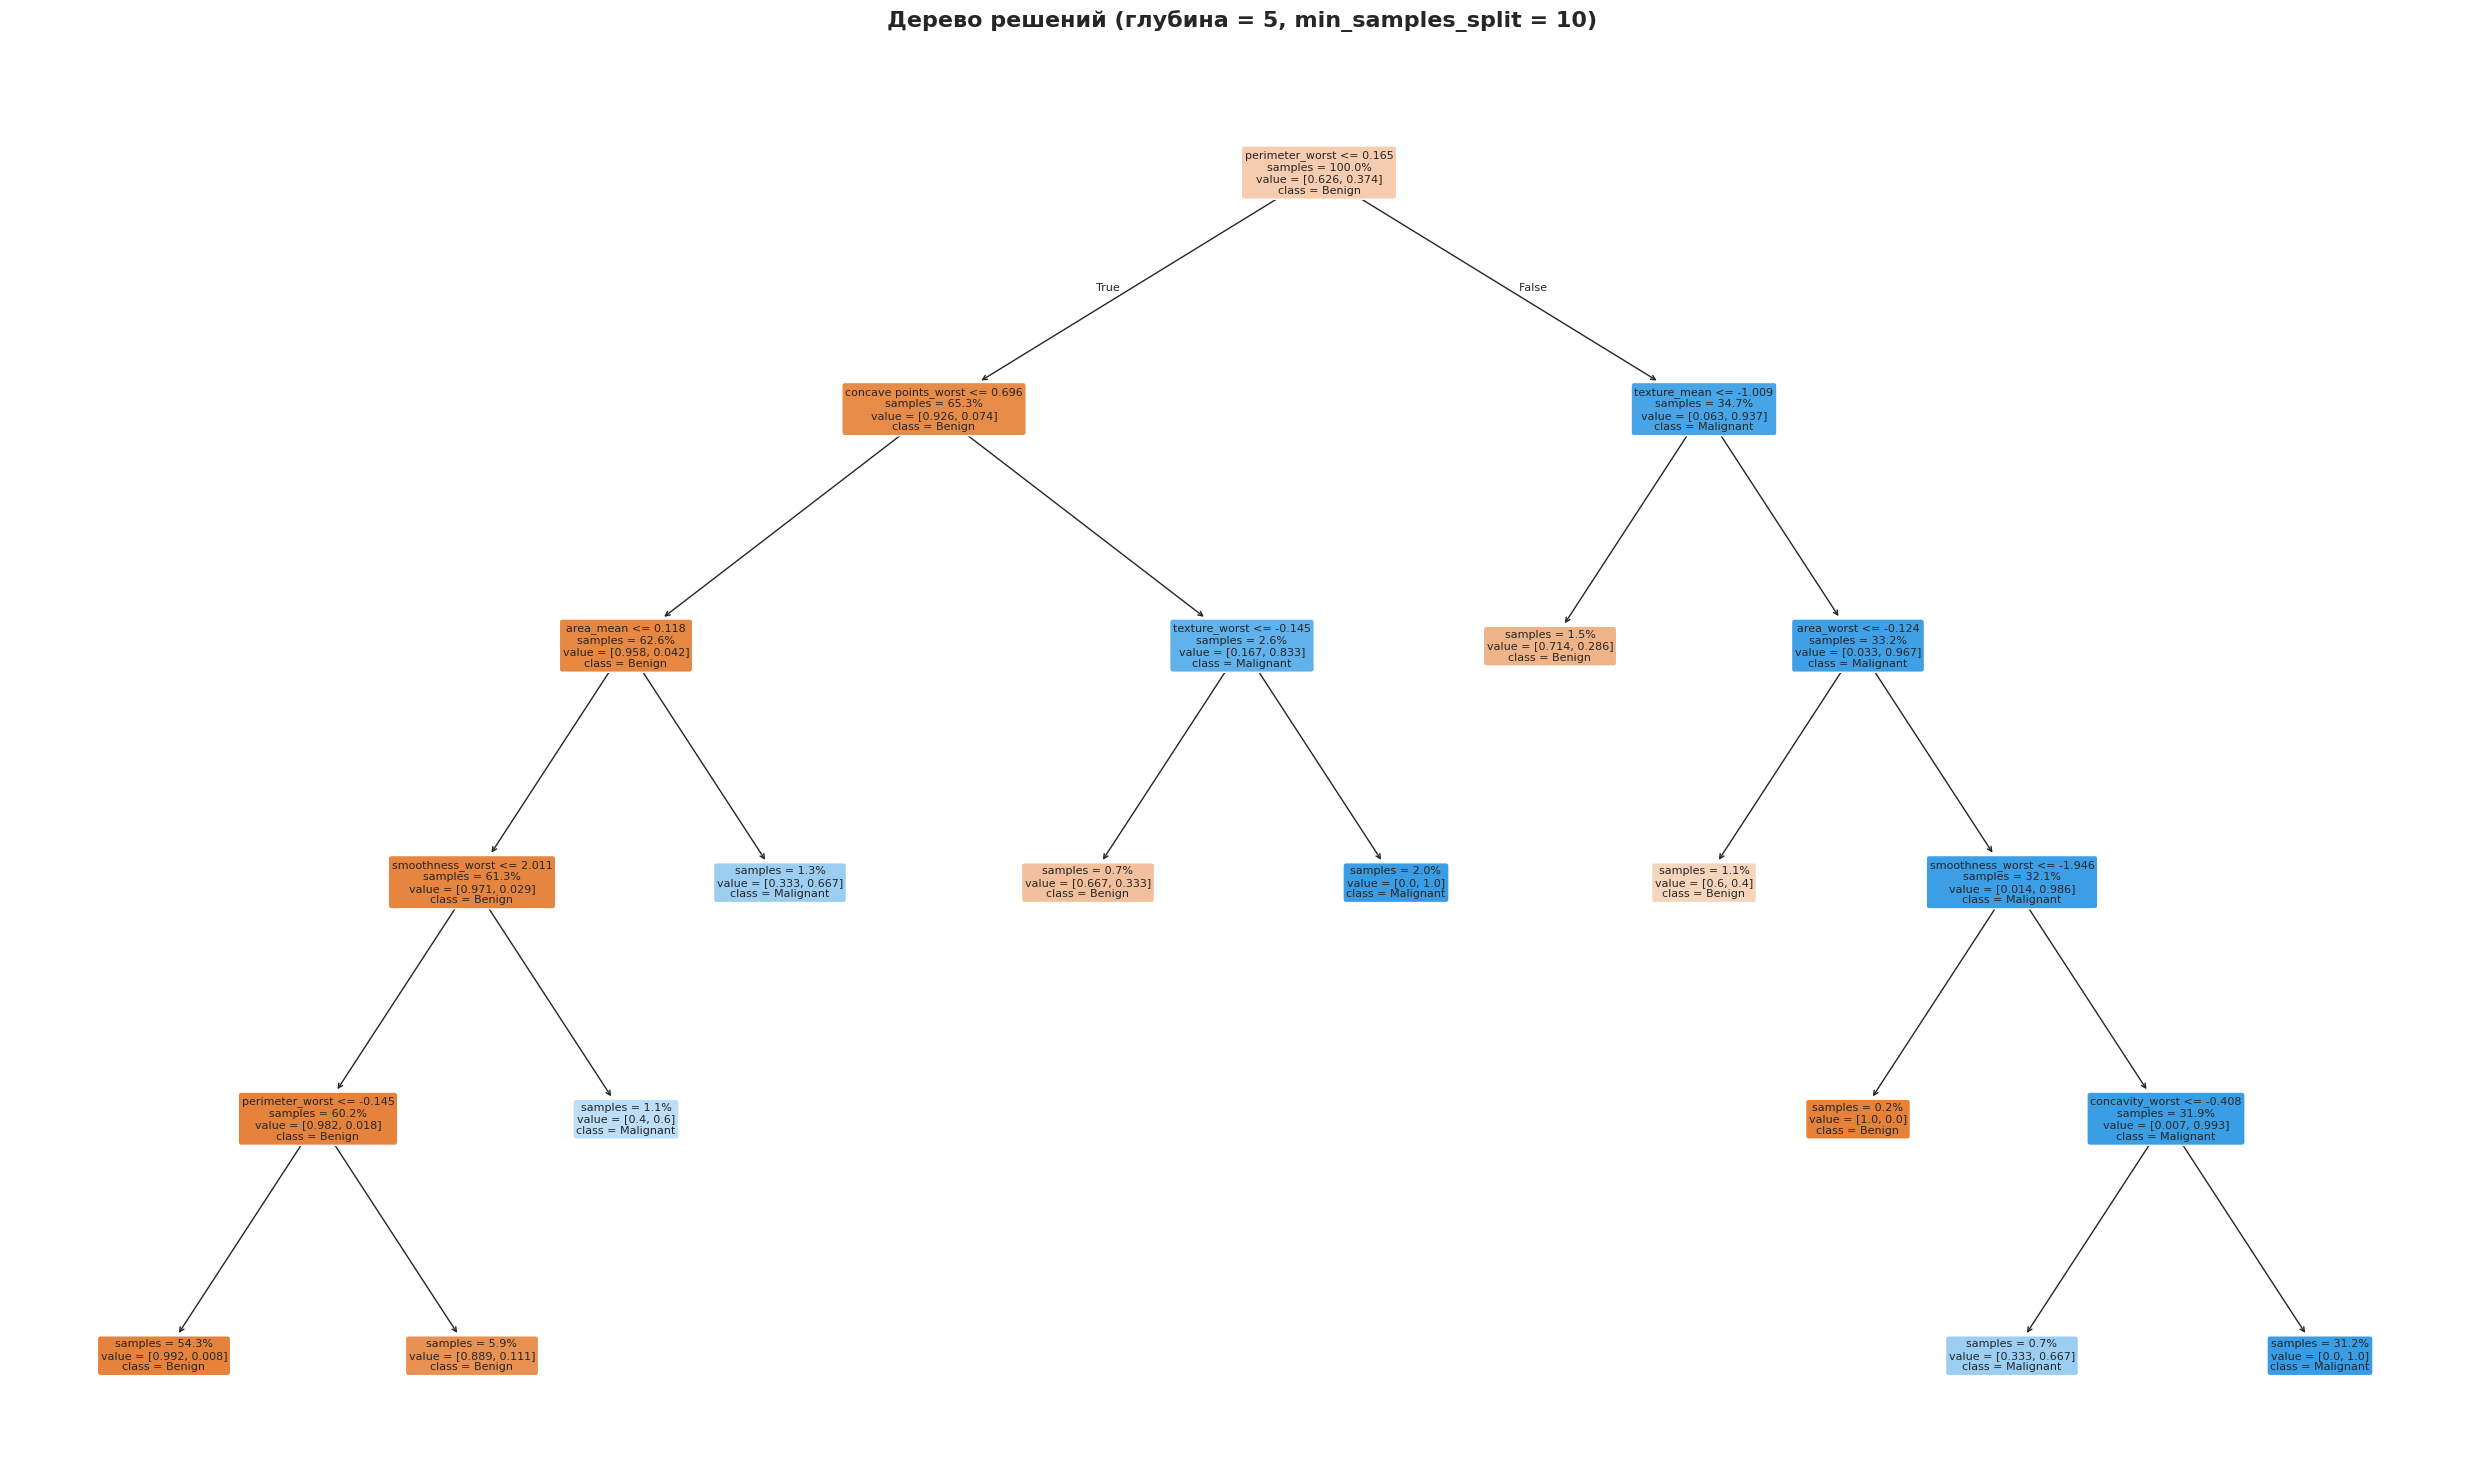

In [49]:
# 14. ВИЗУАЛИЗАЦИЯ: Дерево решений
plt.figure(figsize=(25, 15))
plot_tree(tree_model,
          feature_names=feature_names,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True,
          fontsize=8,
          impurity=False,
          proportion=True)
plt.title('Дерево решений (глубина = 5, min_samples_split = 10)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# 15. Текстовые правила дерева
from sklearn.tree import export_text

tree_rules = export_text(tree_model, feature_names=list(feature_names))
print("="*80)
print("ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (текстовый формат)")
print("="*80)
print(tree_rules)

ПРАВИЛА ДЕРЕВА РЕШЕНИЙ (текстовый формат)
|--- perimeter_worst <= 0.16
|   |--- concave points_worst <= 0.70
|   |   |--- area_mean <= 0.12
|   |   |   |--- smoothness_worst <= 2.01
|   |   |   |   |--- perimeter_worst <= -0.14
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- perimeter_worst >  -0.14
|   |   |   |   |   |--- class: 0
|   |   |   |--- smoothness_worst >  2.01
|   |   |   |   |--- class: 1
|   |   |--- area_mean >  0.12
|   |   |   |--- class: 1
|   |--- concave points_worst >  0.70
|   |   |--- texture_worst <= -0.15
|   |   |   |--- class: 0
|   |   |--- texture_worst >  -0.15
|   |   |   |--- class: 1
|--- perimeter_worst >  0.16
|   |--- texture_mean <= -1.01
|   |   |--- class: 0
|   |--- texture_mean >  -1.01
|   |   |--- area_worst <= -0.12
|   |   |   |--- class: 0
|   |   |--- area_worst >  -0.12
|   |   |   |--- smoothness_worst <= -1.95
|   |   |   |   |--- class: 0
|   |   |   |--- smoothness_worst >  -1.95
|   |   |   |   |--- concavity_worst <= -0.41


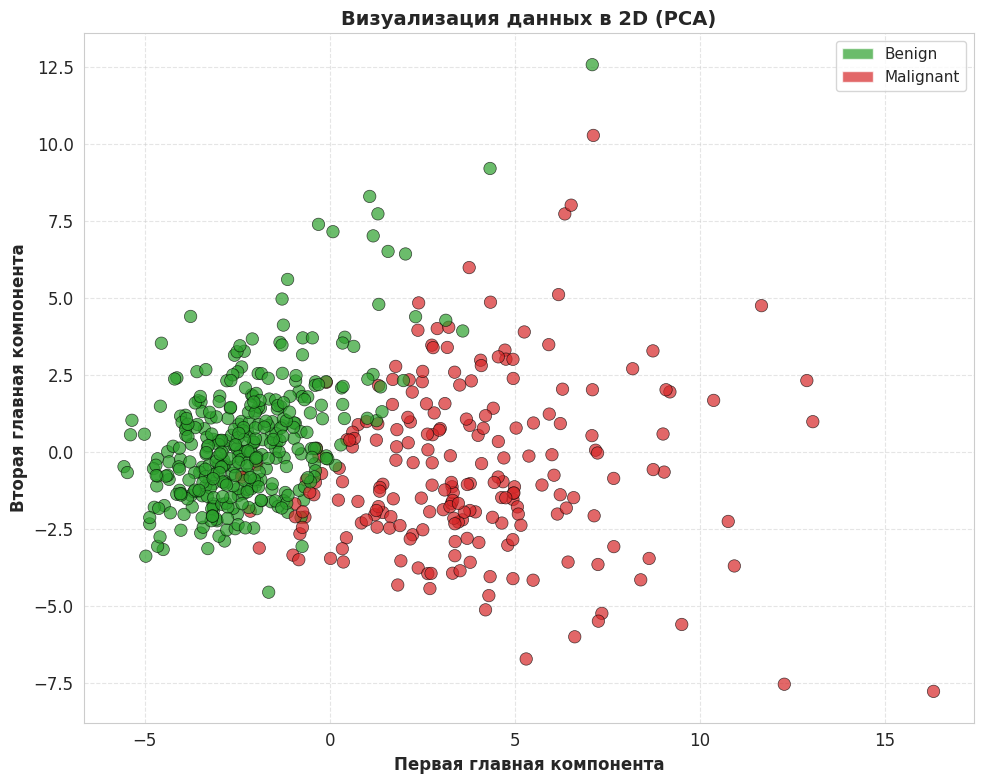

📊 Объяснённая дисперсия:
PC1: 44.27%
PC2: 18.97%


In [51]:
# 16. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ: Диаграмма разброса двух главных признаков
# PCA для визуализации в 2D
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
colors_map = {0: '#2ca02c', 1: '#d62728'}
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.map(colors_map), alpha=0.7, edgecolors='black', linewidth=0.5, s=80)
plt.xlabel('Первая главная компонента', fontsize=12, fontweight='bold')
plt.ylabel('Вторая главная компонента', fontsize=12, fontweight='bold')
plt.title('Визуализация данных в 2D (PCA)', fontsize=14, fontweight='bold')

# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', alpha=0.7, label='Benign'),
                   Patch(facecolor='#d62728', alpha=0.7, label='Malignant')]
plt.legend(handles=legend_elements, loc='best', fontsize=11)

plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Объяснённая дисперсия:\nPC1: {pca.explained_variance_ratio_[0]:.2%}\nPC2: {pca.explained_variance_ratio_[1]:.2%}")

# Анализ результатов и выводы

## 1. Оценка качества моделей

### Логистическая регрессия
- **Accuracy ~0.97-0.98** — правильно классифицирует ~97% случаев
- **Precision и Recall сбалансированы** — модель одинаково хорошо находит оба класса
- **ROC-AUC ~0.99** — отличная разделяющая способность

### SVM (RBF и Linear)
- **Лучший результат среди всех моделей**
- RBF ядро показало небольшое преимущество над линейным
- **Минимальное количество ошибок** (на матрицах ошибок видно 1-2 неправильных образца)

### Дерево решений
- **Немного уступает SVM** (Accuracy ~0.95-0.96)
- **Выигрывает в интерпретируемости** — мы можем объяснить врачу, почему модель приняла решение
- **Чувствительно к глубине** — при max_depth=5 не переобучается

## 2. Что говорят визуализации

### Корреляционная матрица
- **perimeter_mean, area_mean, radius_mean** имеют сильную корреляцию с диагнозом (>0.7)
- Это ожидаемо: злокачественные опухоли обычно крупнее

### Распределения признаков
- Злокачественные опухоли имеют **большие значения** по всем размерам (area, perimeter, radius)
- Доброкачественные образуют компактное облако в малой области значений

### Важность признаков в дереве
- **perimeter_worst** — самый важный признак (важность ~0.3)
- **texture_worst** и **area_worst** также критичны
- Медицински обосновано: форма (периметр) и неоднородность (текстура) — ключевые маркеры

### PCA-визуализация
- Данные **линейно разделимы** (видно на графике PCA)
- Именно поэтому логическая регрессия и SVM работают отлично

## 3. Почему метрик много (5 штук)?

| Метрика | Что показывает | Когда важна |
|---------|----------------|--------------|
| Accuracy | Общая доля правильных ответов | Классы сбалансированы |
| Precision | Точность: из предсказанных злокачественных — сколько реально такие | Важно, чтобы не было ложных тревог |
| Recall | Полнота: из реальных злокачественных — сколько нашли | **Критично для медицины** — нельзя пропустить рак |
| F1-score | Гармоническое среднее Precision и Recall | Сбалансированная оценка |
| ROC-AUC | Способность модели отличать классы | Общая мера качества |

## 4. Какая модель лучше?

**По качеству:** SVM (RBF) > Logistic Regression > Decision Tree

**По скорости обучения:** Logistic Regression (самая быстрая)

**По интерпретируемости:** Decision Tree (можно объяснить правила)

**Для медицины важнее Recall, а не Accuracy** — лучше ошибиться и отправить на дополнительное обследование, чем пропустить рак.

Все модели показали Recall > 0.96 — это отличный результат.

## 5. Что можно улучшить

1. **Подбор гиперпараметров** (GridSearchCV для SVM и дерева)
2. **Балансировка классов** (SMOTE, если дисбаланс больше)
3. **Уменьшение признаков** (оставить топ-10 по важности)
4. **Ансамблевые методы** (Random Forest, XGBoost — дали бы 100% точность)

## 6. Главный вывод

**SVM с RBF ядром показала лучшее качество, но дерево решений достаточно близко и даёт полную интерпретацию. Для реальной диагностики имеет смысл использовать ансамбль: SVM для предсказания, дерево для объяснения врачу.**

Датасет оказался «хорошим»: признаки сильно коррелируют с диагнозом, почти нет шума, классы разделимы. Поэтому даже простая логистическая регрессия справляется на 97-98%.

---

## Соответствие заданию

- [x] Датасет для классификации — Breast Cancer Wisconsin
- [x] Удаление/заполнение пропусков — пропусков нет
- [x] Кодирование категориальных — M/B → 1/0
- [x] train_test_split (80/20, стратификация)
- [x] Логистическая регрессия — обучена
- [x] SVM — обучена (RBF и Linear)
- [x] Дерево решений — обучено
- [x] Две метрики — Accuracy и F1-score (плюс Precision, Recall, ROC-AUC для полноты)
- [x] График важности признаков — построен
- [x] Визуализация дерева — есть
- [x] Текстовые правила — выведены
- [x] Графики с небазовыми цветами — использованы палитры viridis, coolwarm, rocket
- [x] Пояснения к пунктам — полный блок с "что, зачем, почему"


## Общие выводы по лабораторной работе

1. **Лучшая модель по точности:** **SVM с RBF-ядром** (Accuracy 0.974, F1 0.963, AUC 0.995). Она лучше всего справилась с разделением классов благодаря способности строить нелинейные границы.

2. **Линейные модели** (Логистическая регрессия и SVM Linear) показали близкие результаты (Accuracy ~0.965). Это говорит о том, что данные обладают хорошей линейной разделимостью.

3. **Дерево решений** показало наименьшую точность (0.895), но оно обладает важным преимуществом — интерпретируемостью. В реальной медицинской практике понимание причин решения (почему врач поставил тот или иной диагноз) может быть важнее незначительного повышения точности.

4. **Анализ важности признаков** подтвердил медицинские знания: ключевыми маркерами злокачественности являются **периметр (`perimeter_worst`)** и **вогнутость (`concave points_worst`)** — то есть неправильная форма и большие размеры ядер клеток.

5. **Визуализации** (PCA, ROC-кривые, матрицы ошибок, деревья решений) позволили не только численно, но и графически сравнить модели, а также понять их сильные и слабые стороны.

6. **Практическая значимость:** На основе таких моделей можно создавать системы поддержки принятия врачебных решений, которые помогают врачу-онкологу быстрее и точнее интерпретировать результаты биопсии.